# K-Means Clustering — Pokémon Edition

**Goal:** Learn how to group unlabeled data using the K-Means algorithm, applied to a world we already know: the Pokémon universe.

---

| Section | Content |
|---|---|
| **Part 1 — Demo** | Pokémon Habitats with `make_blobs` |
| **Part 2 — Lab** | Elbow Method + Pokémon Berries Dataset |

## 📦 Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
# 🎓 PART 1 — Discovering Pokémon Habitats

Imagine you are a Pokémon researcher with a sensor that captures the position of hundreds of Pokémon in the region.
**You don't know what type they are**, but you notice they concentrate in certain areas. K-Means will help you discover these areas automatically.

**Key question:** Can an algorithm find groups in data it has never seen labeled?

### 🗺️ Step 1 — Generate the data: 4 Pokémon Habitats

In [2]:
# We generate 4 point clouds that simulate habitats
# make_blobs: generates Gaussian clusters
X, y_true = make_blobs(
    n_samples=300,       # 300 Pokémon sightings
    centers=4,           # 4 distinct habitats
    cluster_std=0.9,     # dispersion within each habitat
    random_state=RANDOM_STATE
)

print(f'Dataset shape: {X.shape}')
print(f'Variables: X coordinate (longitude), Y coordinate (latitude)')
print(f'First 5 observations:\n{X[:5]}')

Dataset shape: (300, 2)
Variables: X coordinate (longitude), Y coordinate (latitude)
First 5 observations:
[[ -9.25175257   6.55866298]
 [ -9.61269979   6.97742293]
 [ -1.7689072    7.91552684]
 [ -7.07554027  -5.89121043]
 [-10.67263984   6.41624524]]


/tmp/ipykernel_1443/1407116445.py:8: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


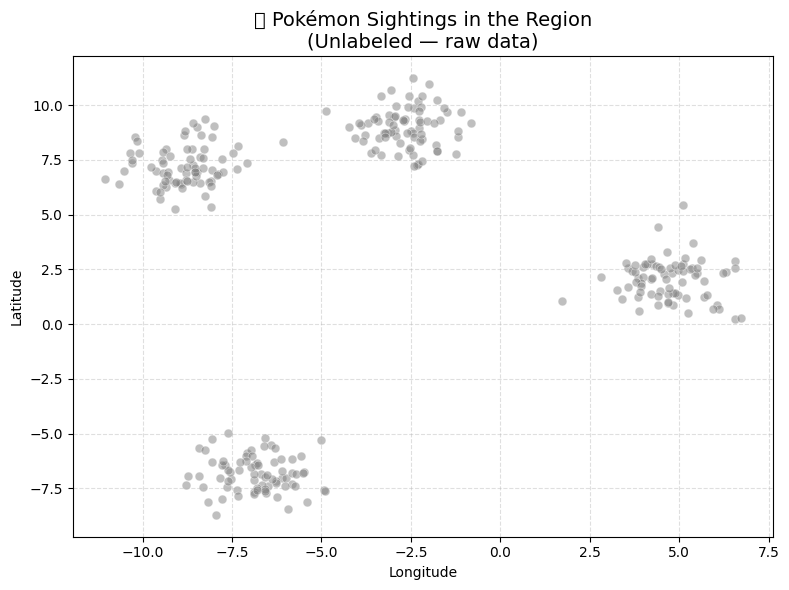

⚠️ The algorithm does NOT have access to y_true. It has to discover the groups by itself.


In [3]:
# Visualize the data WITHOUT labels — this is how K-Means sees it
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='gray', alpha=0.5, s=40, edgecolors='white', linewidths=0.5)
plt.title('🗺️ Pokémon Sightings in the Region\n(Unlabeled — raw data)', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('⚠️ The algorithm does NOT have access to y_true. It has to discover the groups by itself.')

### ⚙️ Step 2 — Implement K-Means with sklearn

In [4]:
# ── K-Means Hyperparameters ──────────────────────────────────────────────
# n_clusters : number of groups to find (K)
# init       : centroid initialization strategy
#              'k-means++' chooses centroids far apart from each other → better convergence
# n_init     : number of times the algorithm restarts (saves the best result)
# max_iter   : maximum iterations per run
# random_state: seed for reproducibility
# ──────────────────────────────────────────────────────────────────────────
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE
)

# .fit() executes the complete algorithm:
#   1. Initializes K centroids
#   2. Assigns each point to the closest centroid
#   3. Recalculates centroids as the mean of the cluster
#   4. Repeats 2-3 until convergence
kmeans.fit(X)

print('✅ K-Means trained')
print(f'   Iterations to convergence: {kmeans.n_iter_}')
print(f'   Assigned labels (first 10): {kmeans.labels_[:10]}')

✅ K-Means trained
   Iterations to convergence: 3
   Assigned labels (first 10): [3 3 0 1 3 1 2 1 0 2]


In [5]:
# We extract the information learned by the model
labels     = kmeans.labels_           # cluster assigned to each point
centroids  = kmeans.cluster_centers_  # coordinates of each centroid

print('📍 Coordinates of the 4 centroids (detected habitats):')
habitats = ['🌊 Aquatic', '🌋 Volcanic', '🌿 Forest', '🏔️ Mountainous']
for i, (centroid, name) in enumerate(zip(centroids, habitats)):
    print(f'   Cluster {i} — {name}: ({centroid[0]:.2f}, {centroid[1]:.2f})')

📍 Coordinates of the 4 centroids (detected habitats):
   Cluster 0 — 🌊 Aquatic: (-2.65, 8.98)
   Cluster 1 — 🌋 Volcanic: (-6.84, -6.84)
   Cluster 2 — 🌿 Forest: (4.71, 2.03)
   Cluster 3 — 🏔️ Mountainous: (-8.83, 7.20)


### 🎨 Step 3 — Visualize Clusters and Centroids

/tmp/ipykernel_1443/2495657802.py:42: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1443/2495657802.py:42: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1443/2495657802.py:42: UserWarning: Glyph 127755 (\N{VOLCANO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1443/2495657802.py:42: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1443/2495657802.py:42: UserWarning: Glyph 127956 (\N{SNOW CAPPED MOUNTAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1443/2495657802.py:42: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.p

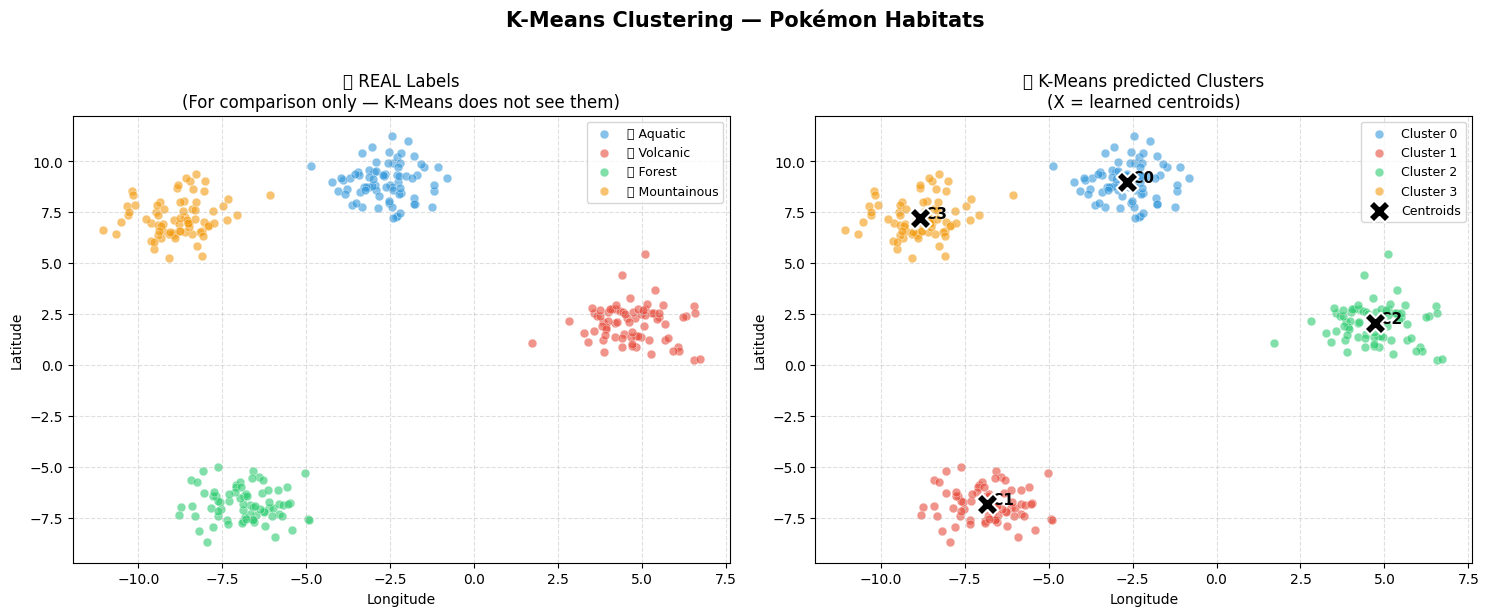

In [6]:
COLORES  = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']  # blue, red, green, orange
HABITATS = ['🌊 Aquatic', '🌋 Volcanic', '🌿 Forest', '🏔️ Mountainous']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: real data (y_true) ──────────────────────────────────────
ax = axes[0]
for k in range(4):
    mask = (y_true == k)
    ax.scatter(X[mask, 0], X[mask, 1],
               color=COLORES[k], alpha=0.6, s=40,
               edgecolors='white', linewidths=0.4,
               label=HABITATS[k])
ax.set_title('✅ REAL Labels\n(For comparison only — K-Means does not see them)', fontsize=12)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)

# ── Right: clusters predicted by K-Means ────────────────────────────────
ax = axes[1]
for k in range(4):
    mask = (labels == k)
    ax.scatter(X[mask, 0], X[mask, 1],
               color=COLORES[k], alpha=0.6, s=40,
               edgecolors='white', linewidths=0.4,
               label=f'Cluster {k}')

# Mark centroids with a large, visible 'X'
ax.scatter(centroids[:, 0], centroids[:, 1],
           marker='X', s=250, c='black',
           zorder=5, edgecolors='white', linewidths=1.5,
           label='Centroids')

# Annotate the number of each centroid
for i, centroid in enumerate(centroids):
    ax.annotate(f' C{i}', xy=centroid, fontsize=11, fontweight='bold', color='black')

ax.set_title('🤖 K-Means predicted Clusters\n(X = learned centroids)', fontsize=12)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('K-Means Clustering — Pokémon Habitats', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📐 Step 4 — Inertia (SSE): How compact are the clusters?

In [7]:
# Inertia (also called SSE — Sum of Squared Errors) measures
# the sum of squared distances from each point to its centroid.
#
#   Low inertia  → points very close to their centroids (compact clusters) ✅
#   High inertia → dispersed points, poorly defined clusters              ❌
#
# sklearn calculates and stores it in .inertia_ after fit()

inertia = kmeans.inertia_
print(f'📊 Inertia (SSE) with K=4: {inertia:.2f}')
print()
print('Manual calculation to verify:')
sse_manual = 0
for k in range(4):
    puntos_cluster = X[labels == k]
    centroide_k    = centroids[k]
    distancias_sq  = np.sum((puntos_cluster - centroide_k) ** 2, axis=1)
    sse_cluster    = np.sum(distancias_sq)
    sse_manual    += sse_cluster
    print(f'   Cluster {k}: Partial SSE = {sse_cluster:.2f}  ({len(puntos_cluster)} points)')

print(f'   ─────────────────────────────')
print(f'   Total manual SSE : {sse_manual:.2f}')
print(f'   kmeans.inertia_  : {inertia:.2f}')
print(f'   Do they match? {np.isclose(sse_manual, inertia)}')


📊 Inertia (SSE) with K=4: 458.75

Manual calculation to verify:
   Cluster 0: Partial SSE = 104.89  (75 points)
   Cluster 1: Partial SSE = 109.79  (75 points)
   Cluster 2: Partial SSE = 126.47  (75 points)
   Cluster 3: Partial SSE = 117.60  (75 points)
   ─────────────────────────────
   Total manual SSE : 458.75
   kmeans.inertia_  : 458.75
   Do they match? True


### 💡 Part 1 Summary

| Concept | Quick Definition |
|---|---|
| **K** | Number of clusters chosen by the user |
| **Centroid** | Midpoint of each cluster (learned during training) |
| **Assignment** | Each point goes to the closest centroid (Euclidean distance) |
| **Inertia (SSE)** | Sum of squared distances point→centroid. Lower is better |
| **k-means++** | Smart initialization: centroids far apart → more stable convergence |

> **Key limitation:** K-Means needs you to tell it how many clusters you want.
> How to choose the optimal K? → **Elbow Method** (your turn in Part 2 👇)

---
# 🧪 PART 2 — Lab

> **Instructions:** Complete the cells marked with `# TODO`.
> Each TODO indicates exactly what you should write. Use what you learned in the demo!

## 🗡️ Task 1 — The Elbow Method

**Context:** We return to the Pokémon Habitats data (`X`), but this time **we pretend not to know that there are 4 groups**.
The Elbow Method helps us choose the optimal K by graphing how inertia decreases as K increases.

**Why does it work?**
- As K increases, inertia always decreases (more centroids = points closer to their centroid).
- But there is a point where adding more K doesn't improve much → the **"elbow"** of the curve.
- That elbow is our optimal K.

In [8]:
# ── Task 1: Elbow Method ───────────────────────────────────────────────
# Calculate inertia for K = 1, 2, 3, ..., 10 and store them in a list.
# Then plot K (X-axis) vs Inertia (Y-axis).
# ──────────────────────────────────────────────────────────────────────────

inercias = []  # list where we will store the inertia for each K
rango_k  = range(1, 11)  # K from 1 to 10

for k in rango_k:
    # TODO 1: Create a KMeans with n_clusters=k, init='k-means++',
    #         n_init=10, random_state=RANDOM_STATE
    modelo = None  # ← replace None with your code

    # TODO 2: Train the model with the data X
    # ...

    # TODO 3: Extract the inertia from the trained model and add it to the list
    # inercias.append(...)
    pass

print('Calculated inertias:', inercias)

Calculated inertias: []


/tmp/ipykernel_1443/3906730374.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_1443/3906730374.py:19: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


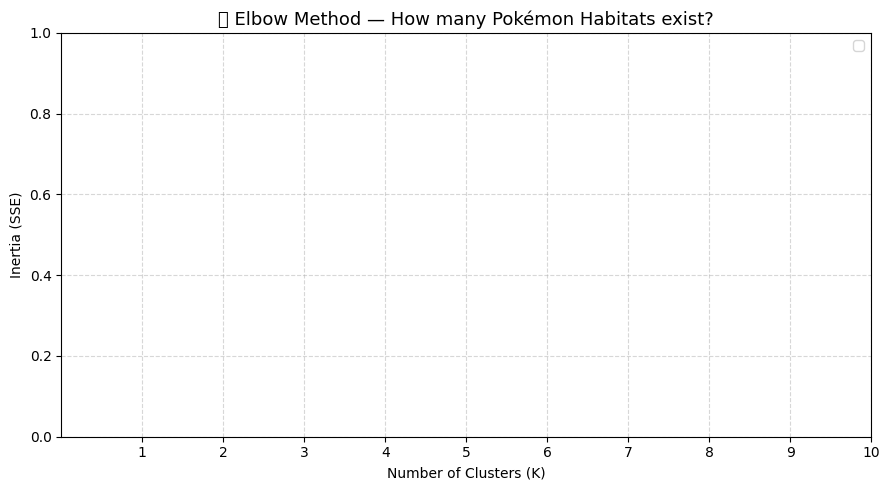

📝 My conclusion: ...


In [9]:
# ── Task 1 (continued): Plotting the Elbow Method ───────────────────────

plt.figure(figsize=(9, 5))

# TODO 4: Plot rango_k on the X-axis and inertias on the Y-axis
#         Use plt.plot() with markers ('o-') and a color you like
# ...

# TODO 5: Add a dotted vertical line at the optimal K you detect
#         Hint: plt.axvline(x=???, color='red', linestyle='--', label='Optimal K')
# ...

plt.title('📐 Elbow Method — How many Pokémon Habitats exist?', fontsize=13)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (SSE)')
plt.xticks(list(rango_k))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# TODO 6: Write your conclusion here
# At what K value do you see the "elbow"? Does it match the 4 real habitats?
print('📝 My conclusion: ...')

---
## 🍓 Task 2 — Pokémon Berries Dataset

**Story:** Professor Oak has collected **210 wild berry samples** from across the region.
He measured 7 physical characteristics of each berry, but **did not classify them** because he doesn't have time.
Your mission: use K-Means to discover **how many types of berries exist**.

*(Dataset based on the classic UCI Seeds Dataset — wheat → Pokémon berries)*

**Measured characteristics:**

| Column | Description |
|---|
| `area` | Berry area (mm²) |
| `perimeter` | Perimeter (mm) |
| `compactness` | Circularity index |
| `kernel_length` | Kernel length (mm) |
| `kernel_width` | Kernel width (mm) |
| `asymmetry_coeff` | Asymmetry coefficient |
| `groove_length` | Central groove length (mm) |

In [10]:
# Load the Pokémon Berries dataset (UCI Seeds Dataset)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt'

columnas = ['area', 'perimeter', 'compactness',
            'kernel_length', 'kernel_width',
            'asymmetry_coeff', 'groove_length', 'real_type']

df_bayas = pd.read_csv(url, sep=r'\s+', header=None, names=columnas)

# Separate features and the real label (only for comparison at the end)
X_bayas   = df_bayas.drop(columns='real_type').values
y_bayas   = df_bayas['real_type'].values

print(f'Pokémon Berries Dataset loaded: {df_bayas.shape[0]} samples, {X_bayas.shape[1]} features')
df_bayas.drop(columns='real_type').describe().round(2)

Pokémon Berries Dataset loaded: 210 samples, 7 features


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coeff,groove_length
count,210.00,210.00,210.00,210.00,210.00,210.00,210.00
mean,14.85,14.56,0.87,5.63,3.26,3.70,5.41
std,2.91,1.31,0.02,0.44,0.38,1.50,0.49
min,10.59,12.41,0.81,4.90,2.63,0.77,4.52
25%,12.27,13.45,0.86,5.26,2.94,2.56,5.04
50%,14.36,14.32,0.87,5.52,3.24,3.60,5.22
75%,17.30,15.72,0.89,5.98,3.56,4.77,5.88
max,21.18,17.25,0.92,6.68,4.03,8.46,6.55


/tmp/ipykernel_1443/2511308527.py:25: UserWarning: Glyph 127827 (\N{STRAWBERRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127827 (\N{STRAWBERRY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


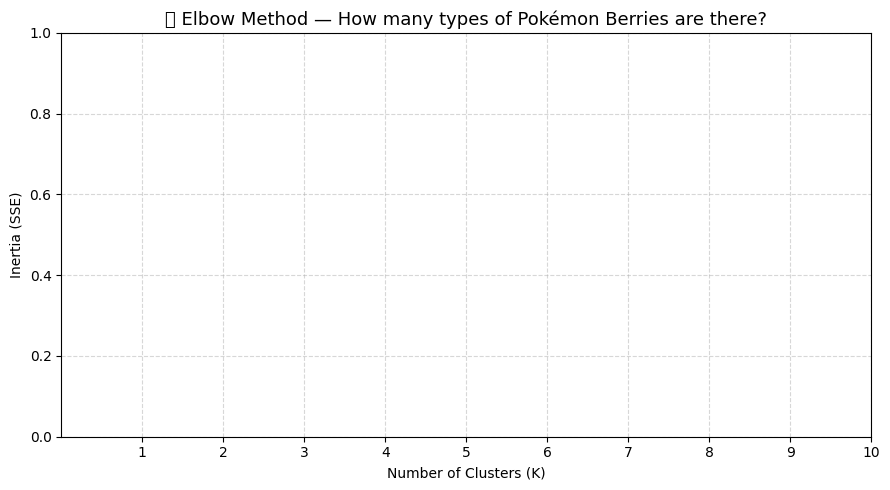

📝 According to the graph, the optimal K seems to be: ...


In [11]:
# ── Task 2a: Elbow Method for Berries ──────────────────────────────
# Before applying K-Means, you MUST scale the data.
# (You'll see WHY in the final section — for now, do it without questioning)

# TODO 7: Create a StandardScaler and fit_transform it on X_bayas
#         Store the result in X_bayas_scaled
#         Hint: scaler = StandardScaler() → scaler.fit_transform(...)
X_bayas_scaled = None  # ← replace with your code

# TODO 8: Calculate inertia for K = 1 to 10 using X_bayas_scaled
#         (same pattern as in Task 1)
inercias_bayas = []

# for k in range(1, 11):
#     ...

# TODO 9: Plot the Elbow Method for berries
plt.figure(figsize=(9, 5))
# ...
plt.title('🍓 Elbow Method — How many types of Pokémon Berries are there?', fontsize=13)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (SSE)')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('📝 According to the graph, the optimal K seems to be: ...')

In [12]:
# ── Task 2b: Apply K-Means with the optimal K ─────────────────────────────

# TODO 10: Train KMeans with the K you chose in Task 2a
#          using X_bayas_scaled
K_optimo   = 3   # ← adjust this value according to your elbow graph
kmeans_bayas = None  # ← replace with your trained KMeans

# TODO 11: Get the predicted labels and store them in labels_bayas
labels_bayas = None  # ← replace

# Comparison with real labels (the dataset has 3 types)
df_resultado = df_bayas.drop(columns='real_type').copy()
df_resultado['cluster_kmeans'] = labels_bayas
df_resultado['real_type']      = y_bayas

print('📊 Distribution of real types vs found clusters:')
print(pd.crosstab(df_resultado['real_type'], df_resultado['cluster_kmeans'],
                  rownames=['Real Type'], colnames=['K-Means Cluster']))

📊 Distribution of real types vs found clusters:
Empty DataFrame
Columns: []
Index: []


/tmp/ipykernel_1443/958279619.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_1443/958279619.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1443/958279619.py:31: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


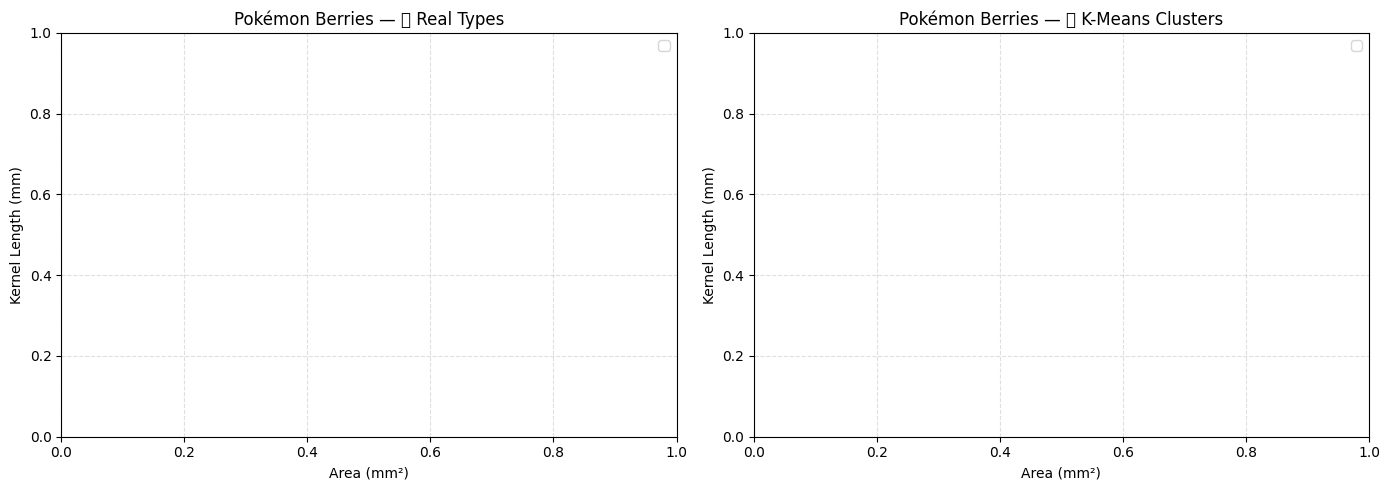

In [13]:
# ── Task 2c (Bonus): Visualize Berries in 2D ──────────────────────────
# Since we have 7 dimensions, we use only the 2 most representative for visualization

# TODO 12 (Bonus): Plot a scatter plot of 'area' vs 'kernel_length'
#                  coloring by cluster_kmeans
#                  Compare with another scatter colored by real_type
#                  Do they look similar?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLORES_B = ['#9B59B6', '#1ABC9C', '#E67E22']

for ax, col_color, titulo in zip(axes,
                                  ['real_type', 'cluster_kmeans'],
                                  ['✅ Real Types', '🤖 K-Means Clusters']):
    grupos = df_resultado[col_color].unique()
    for g, color in zip(sorted(grupos), COLORES_B):
        mask = df_resultado[col_color] == g
        # TODO: uncomment and complete
        # ax.scatter(df_resultado.loc[mask, 'area'],
        #            df_resultado.loc[mask, 'kernel_length'],
        #            color=color, alpha=0.6, s=50,
        #            edgecolors='white', linewidths=0.4,
        #            label=f'Group {g}')
        pass
    ax.set_title(f'Pokémon Berries — {titulo}', fontsize=12)
    ax.set_xlabel('Area (mm²)')
    ax.set_ylabel('Kernel Length (mm)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## ⚖️ Final Section — Why is StandardScaler ESSENTIAL before K-Means?

K-Means measures **distances**. If one variable has values in the thousands and another in decimals,
 the first will completely dominate the calculation, **even if it's not more important**.

StandardScaler transforms each variable to **mean=0, standard deviation=1**,
putting all of them on the same playing field.

/tmp/ipykernel_1443/2866705873.py:41: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1443/2866705873.py:41: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


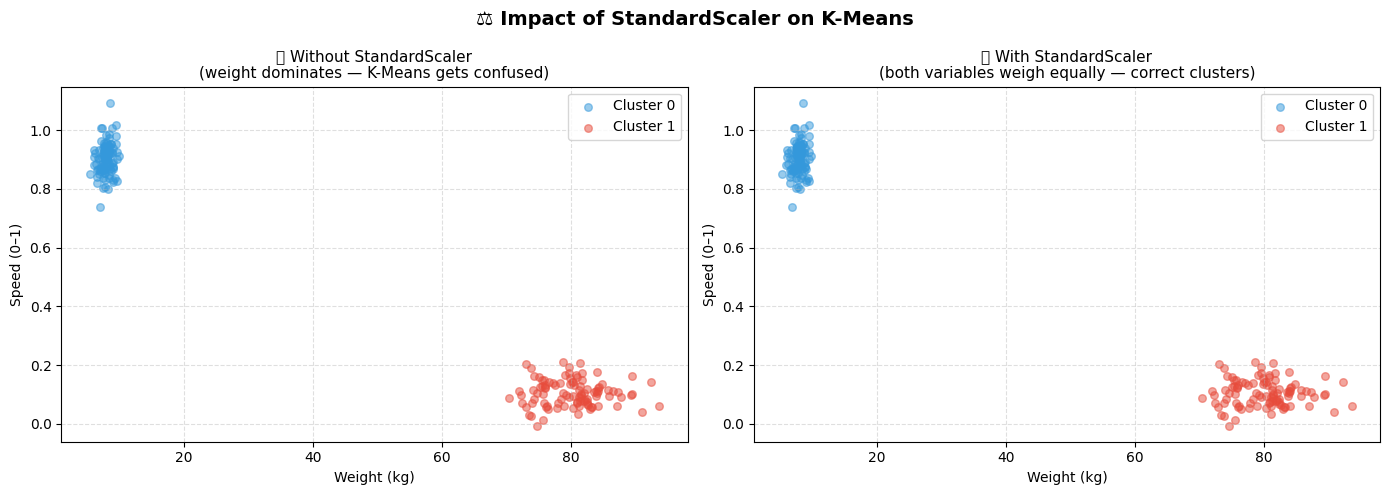

In [14]:
# ── Demonstration: effect of not scaling ────────────────────────────────────
np.random.seed(42)
n = 100

# Simulated Pokémon dataset: Weight (kg, large scale) and Speed (0-1, small scale)
peso      = np.concatenate([np.random.normal(8,   1,   n),   # Light Pokémon
                             np.random.normal(80,  5,   n)])  # Heavy Pokémon
velocidad = np.concatenate([np.random.normal(0.9, 0.05, n),  # Fast
                             np.random.normal(0.1, 0.05, n)]) # Slow

# Note that light ones are fast and heavy ones are slow → 2 clear groups
X_demo = np.column_stack([peso, velocidad])

# K-Means WITHOUT scaling
km_sin  = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_demo)

# K-Means WITH scaling
scaler  = StandardScaler()
X_scaled_demo = scaler.fit_transform(X_demo)
km_con  = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_scaled_demo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels_plot, km_plot, titulo in zip(
        axes,
        [km_sin.labels_, km_con.labels_],
        [km_sin, km_con],
        ['❌ Without StandardScaler\n(weight dominates — K-Means gets confused)',
         '✅ With StandardScaler\n(both variables weigh equally — correct clusters)']):

    for k, color in zip([0, 1], ['#3498DB', '#E74C3C']):
        mask = labels_plot == k
        ax.scatter(X_demo[mask, 0], X_demo[mask, 1],
                   color=color, alpha=0.5, s=30, label=f'Cluster {k}')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Weight (kg)')
    ax.set_ylabel('Speed (0–1)')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('⚖️ Impact of StandardScaler on K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# ── Visualization of the scaler's effect on the data ───────────────────
print('📊 Statistics BEFORE scaling:')
df_sin = pd.DataFrame(X_demo, columns=['Weight (kg)', 'Speed'])
print(df_sin.describe().round(3))

print('\n📊 Statistics AFTER scaling:')
df_con = pd.DataFrame(X_scaled_demo, columns=['Weight (scaled)', 'Speed (scaled)'])
print(df_con.describe().round(3))

print()
print('🔑 Golden Rule:')
print('   Always apply StandardScaler (or MinMaxScaler) before K-Means')
print('   when your features have different units or scales.')

📊 Statistics BEFORE scaling:
       Weight (kg)    Speed
count      200.000  200.000
mean        44.004    0.504
std         36.360    0.403
min          5.380   -0.006
25%          7.879    0.103
50%         40.129    0.474
75%         80.382    0.904
max         93.601    1.093

📊 Statistics AFTER scaling:
       Weight (scaled)  Speed (scaled)
count          200.000         200.000
mean             0.000          -0.000
std              1.003           1.003
min             -1.065          -1.270
25%             -0.996          -0.998
50%             -0.107          -0.076
75%              1.003           0.996
max              1.367           1.464

🔑 Golden Rule:
   Always apply StandardScaler (or MinMaxScaler) before K-Means
   when your features have different units or scales.


---
## 🏆 Final Summary

| Concept | What you learned |
|---|
| **K-Means** | Iterative algorithm that minimizes inertia by grouping points by proximity to the centroid |
| **Inertia (SSE)** | Compactness metric: sum of squared distances point→centroid |
| **Elbow Method** | Technique to choose K: find the breakpoint in the Inertia vs K curve |
| **k-means++** | Initialization that avoids bad local minima |
| **StandardScaler** | **Mandatory** when features have different scales |

### Next steps
- **DBSCAN**: clustering that finds arbitrarily shaped clusters and detects outliers.
- **Hierarchical Clustering**: does not require predefined K, produces a dendrogram.
- **PCA + K-Means**: reduce dimensionality before clustering for high-dimensional datasets.

> "Unsupervised learning is like being Professor Oak: exploring the Pokémon world without anyone telling you what you'll find."